# 🏢 Análise de Mercado Imobiliário com Dados do Airbnb

## 📌 Objetivo
Desenvolver uma ferramenta de análise estratégica para identificar bairros com maior potencial de investimento em aluguel de curta temporada.

## 🎯 Problema de Negócio
Investidores e imobiliárias precisam decidir onde investir com base em dados, não apenas percepção.

Este projeto calcula:
- Receita anual estimada
- Taxa de ocupação
- ROI estimado
- Score estratégico de investimento por bairro

## 📊 Fonte de Dados
Base pública do Airbnb (listings.csv)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

print("Selecione o arquivo listings.csv")
uploaded = files.upload()
arquivo = list(uploaded.keys())[0]

Selecione o arquivo listings.csv


Saving listings.csv to listings.csv


In [ ]:
def carregar_dados(arquivo):
    """
    Carrega o dataset do Airbnb e exibe dimensões básicas.
    """
    df = pd.read_csv(arquivo)
    print(f"Dataset carregado: {df.shape[0]} linhas e {df.shape[1]} colunas")
    return df

df = carregar_dados(arquivo)
df.head()

Dataset carregado: 43068 linhas e 18 colunas


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,821198084644106078,Bright and Peaceful Leblon Loft,84350716,Katrina,NaN,Leblon,-22.982818,-43.222457,Entire home/apt,580.0,2,86,2025-09-19,2.72,1,82,40,NaN
1,821198370698658112,Copacabana 100% reformado.,4347269,Patrick,NaN,Copacabana,-22.984090,-43.191770,Entire home/apt,1900.0,5,0,NaN,NaN,2,364,0,NaN
2,821200521820144734,hambiente familia,499903412,Vanessa,NaN,Pavuna,-22.814911,-43.379011,Entire home/apt,700.0,1,0,NaN,NaN,2,365,0,NaN
3,821213014263313420,Amazing en suite bedroom Leblon,449763717,Alvaro,NaN,Leblon,-22.981910,-43.225990,Private room,NaN,2,3,2024-05-02,0.10,2,0,0,NaN
4,821223043903573522,Incrível apartamento frente mar,25961210,Katia,NaN,Barra da Tijuca,-23.010000,-43.344820,Entire home/apt,500.0,2,11,2025-08-26,0.60,1,234,10,NaN


In [ ]:
# Selecionamos apenas as colunas estratégicas para análise
colunas = [
    "neighbourhood",
    "price",
    "availability_365",
    "number_of_reviews"
]

df = df[colunas].copy()
df.head()

,neighbourhood,price,availability_365,number_of_reviews
0,Leblon,580.0,82,86
1,Copacabana,1900.0,364,0
2,Pavuna,700.0,365,0
3,Leblon,NaN,0,3
4,Barra da Tijuca,500.0,234,11


In [ ]:
def limpar_precos(df, coluna='price'):
    """
    Remove símbolos monetários e converte preços para formato numérico.
    Também elimina valores inválidos ou iguais a zero.
    """

    # Remove caracteres não numéricos (mantendo vírgula, ponto e sinal negativo)
    df[coluna] = (
        df[coluna]
        .astype(str)
        .str.replace(r'[^\d,.-]', '', regex=True)
        .str.replace(',', '.', regex=False)
    )

    # Converte para número (valores inválidos viram NaN)
    df[coluna] = pd.to_numeric(df[coluna], errors='coerce')

    # Remove preços inválidos
    df = df[df[coluna] > 0]

    print(f"Preços válidos após limpeza: {df[coluna].notna().sum()}")
    return df

df = limpar_precos(df)

Preços válidos após limpeza: 38670


In [ ]:
def remover_outliers(df, coluna='price'):
    """
    Remove valores extremos utilizando o método do IQR.
    Isso evita distorções nas médias causadas por anúncios atípicos.
    """

    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)
    iqr = q3 - q1

    df = df[
        (df[coluna] >= q1 - 1.5 * iqr) &
        (df[coluna] <= q3 + 1.5 * iqr)
    ]

    print(f"Linhas após remoção de outliers: {df.shape[0]}")
    return df

df = remover_outliers(df)
df = df.dropna()

Linhas após remoção de outliers: 34878


In [ ]:
def calcular_metricas(df, fator_valor_imovel=1200):
    """
    Calcula métricas estratégicas para avaliação de investimento.

    fator_valor_imovel: multiplicador utilizado para estimar
    o valor total do imóvel com base na diária média.
    """

    # Receita anual estimada:
    # Assume que dias indisponíveis representam dias alugados
    df['receita_anual_estimada'] = df['price'] * (365 - df['availability_365'])

    # Taxa de ocupação percentual
    df['taxa_ocupacao'] = (
        (365 - df['availability_365']) / 365
    ) * 100

    # Estimativa simplificada do valor do imóvel
    valor_imovel_estimado = df['price'] * fator_valor_imovel

    # ROI estimado (%)
    df['roi_estimado'] = (
        df['receita_anual_estimada'] / valor_imovel_estimado
    ) * 100

    return df

df = calcular_metricas(df)
df.head()

,neighbourhood,price,availability_365,number_of_reviews,receita_anual_estimada,taxa_ocupacao,roi_estimado
0,Leblon,580.0,82,86,164140.0,77.534247,23.583333
2,Pavuna,700.0,365,0,0.0,0.000000,0.000000
4,Barra da Tijuca,500.0,234,11,65500.0,35.890411,10.916667
5,Copacabana,461.0,113,89,116172.0,69.041096,21.000000
7,Leme,281.0,32,23,93573.0,91.232877,27.750000


In [ ]:
def analisar_bairros(df):
    """
    Agrupa os dados por bairro e calcula métricas médias.
    Cria um score estratégico ponderado para ranking.
    """

    analise = df.groupby('neighbourhood').agg({
        'price': 'mean',
        'receita_anual_estimada': 'mean',
        'taxa_ocupacao': 'mean',
        'roi_estimado': 'mean',
        'number_of_reviews': 'mean'
    }).round(2)

    # Score ponderado:
    # 40% ROI (rentabilidade)
    # 30% Ocupação (demanda)
    # 20% Avaliações (engajamento)
    # 10% Preço médio (posicionamento)
    analise['score_investimento'] = (
        analise['roi_estimado'].rank(pct=True) * 0.4 +
        analise['taxa_ocupacao'].rank(pct=True) * 0.3 +
        analise['number_of_reviews'].rank(pct=True) * 0.2 +
        analise['price'].rank(pct=True) * 0.1
    )

    return analise.sort_values('score_investimento', ascending=False)

analise = analisar_bairros(df)
analise.head(10)

,price,receita_anual_estimada,taxa_ocupacao,roi_estimado,number_of_reviews,score_investimento
neighbourhood,,,,,,
Leblon,539.03,99114.28,51.55,15.68,40.88,0.953642
Ipanema,500.09,91670.80,50.92,15.49,44.18,0.945695
Urca,382.06,67778.43,52.23,15.89,31.50,0.945033
Copacabana,356.58,63664.55,50.37,15.32,36.00,0.914901
Botafogo,315.08,55016.84,50.65,15.41,30.00,0.901325
Portuguesa,186.72,31431.50,52.94,16.10,41.83,0.898013
Cavalcanti,126.11,28334.89,79.30,24.12,30.89,0.885430
Leme,382.02,66553.55,48.22,14.67,28.07,0.884768
Engenheiro Leal,167.00,48473.00,79.18,24.08,28.67,0.882781


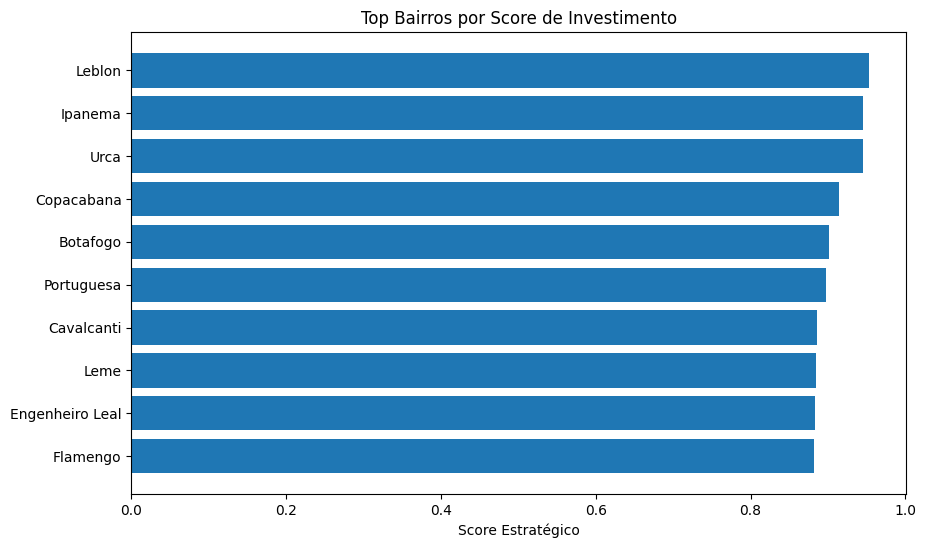

In [ ]:
def criar_dashboard(analise, top_n=10):
    """
    Cria visualização dos bairros com maior score de investimento.
    """

    top = analise.head(top_n)

    plt.figure(figsize=(10,6))
    plt.barh(top.index, top['score_investimento'])
    plt.title("Top Bairros por Score de Investimento")
    plt.xlabel("Score Estratégico")
    plt.gca().invert_yaxis()
    plt.show()

criar_dashboard(analise)

In [ ]:
def criar_dashboard_completo(analise, top_n=10):
    """
    Cria painel visual com os principais indicadores estratégicos.

    Parâmetros:
    analise (DataFrame): Resultado da função analisar_bairros
    top_n (int): Quantidade de bairros a exibir
    """

    print("\n📊 GERANDO DASHBOARD VISUAL")
    print("=" * 40)

    top = analise.head(top_n)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle("🏢 Dashboard Estratégico - Mercado Airbnb", fontsize=16, fontweight='bold')

    # 🔹 1. Score de investimento
    axes[0, 0].barh(top.index, top['score_investimento'])
    axes[0, 0].set_title("Top Bairros por Score de Investimento")
    axes[0, 0].invert_yaxis()

    # 🔹 2. ROI Médio
    axes[0, 1].barh(top.index, top['roi_estimado'])
    axes[0, 1].set_title("ROI Médio (%)")
    axes[0, 1].invert_yaxis()

    # 🔹 3. Receita anual média
    axes[1, 0].barh(top.index, top['receita_anual_estimada'])
    axes[1, 0].set_title("Receita Anual Média (R$)")
    axes[1, 0].invert_yaxis()

    # 🔹 4. Taxa de Ocupação
    axes[1, 1].barh(top.index, top['taxa_ocupacao'])
    axes[1, 1].set_title("Taxa de Ocupação Média (%)")
    axes[1, 1].invert_yaxis()

    plt.tight_layout()
    plt.show()


📊 GERANDO DASHBOARD VISUAL


/tmp/ipykernel_1502/2589701112.py:38: UserWarning: Glyph 127970 (\N{OFFICE BUILDING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127970 (\N{OFFICE BUILDING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


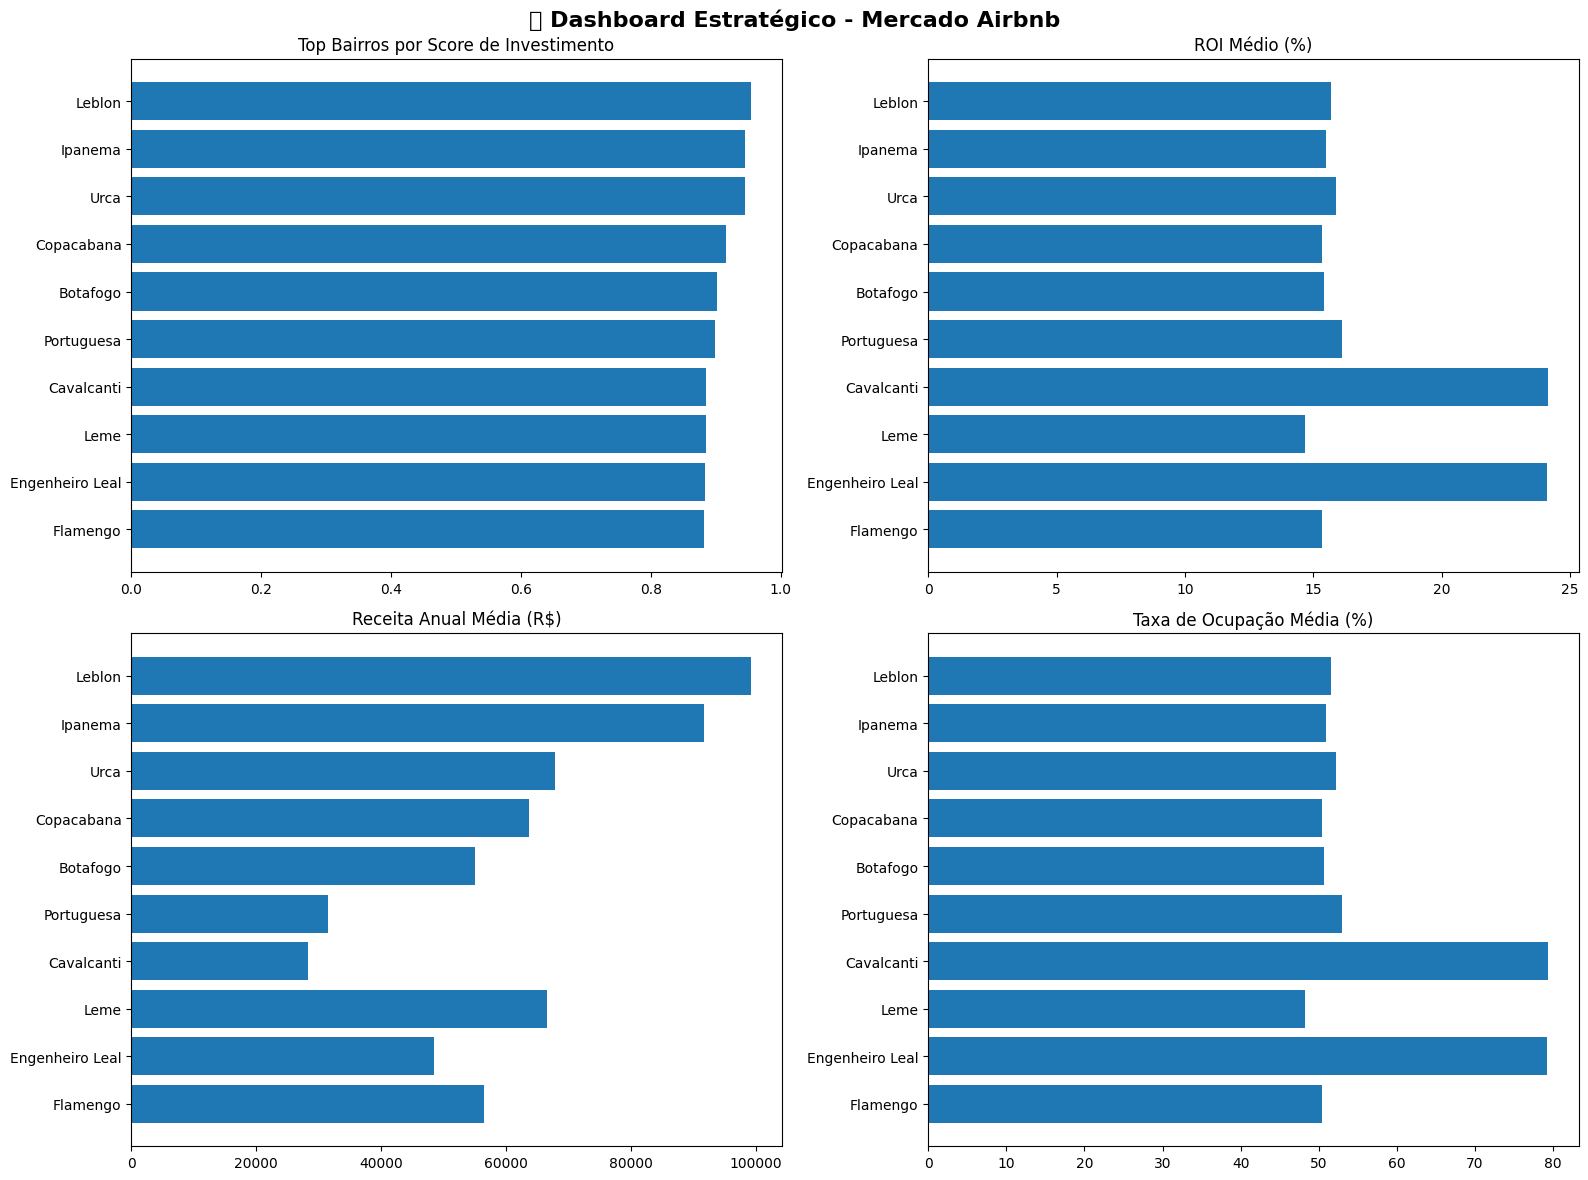

In [ ]:
# Executar dashboard
criar_dashboard_completo(analise)

In [ ]:
def exportar_resultados(df, analise, nome_arquivo="analise_airbnb.xlsx"):
    """
    Exporta dados tratados e ranking final para Excel.
    """

    with pd.ExcelWriter(nome_arquivo) as writer:
        df.to_excel(writer, sheet_name="Base_Tratada", index=False)
        analise.to_excel(writer, sheet_name="Ranking_Bairros")

    print(f"\n✅ Arquivo exportado com sucesso: {nome_arquivo}")

In [ ]:
exportar_resultados(df, analise)


✅ Arquivo exportado com sucesso: analise_airbnb.xlsx


In [ ]:
from google.colab import files
files.download("analise_airbnb.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## ⚠️ Limitações do Modelo

- O ROI é estimado com base em fator simplificado.
- Não considera custos operacionais (condomínio, manutenção, impostos).
- A taxa de ocupação é inferida a partir da disponibilidade anual.
- Não considera sazonalidade ou variações mensais.
- Os dados representam apenas imóveis ativos na plataforma.

Apesar das simplificações, o modelo fornece uma visão estratégica comparativa entre bairros.